In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

Last fuel report fs01:  2026-08-26 23:03:07.881 Last fuel report fs02:  2026-08-18 18:05:10.107
No hay reporte de combustible desde el 26-08-2026.

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [23]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1.csv',sep=',',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Downloads\Export.xlsx') #excel
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1031 entries, 0 to 1030
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1031 non-null   str  
 1   Message  1031 non-null   str  
 2   Status   1031 non-null   str  
dtypes: str(3)
memory usage: 24.3 KB


In [24]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [25]:
#I must deleted 3 last elements of the messahe because of an error that mix fuel sensor 1 with fuel sensor 2.
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
fs01_raw_data=[]
date_fs02_dec_value=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')
    if aux>=100:
        if len(e0x_aux)>0:
            fs01=(e0x_aux[aux:aux+72])
            #print(fs01,e0x_aux)
            if len(fs01)>17:
                msb=fs01[10:12]
                lsb=fs01[8:10]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(e0x.iloc[i,0])            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs01[18:22]=='3E01':
                msb=fs01[28:30]
                lsb=fs01[26:28]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(e0x.iloc[i,0])            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs01[36:40]=='3E01':
                msb=fs01[46:48]
                lsb=fs01[44:46]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(e0x.iloc[i,0])            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs01[58:64]=='3E01':
                msb=fs01[64:66]
                lsb=fs01[62:64]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(e0x.iloc[i,0])            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if aux>100:
        if len(e0x_aux)>0:
            fs02=(e0x_aux[aux:aux+72])
            if len(fs02)>17:
                msb=fs02[10:12]
                lsb=fs02[8:10]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(e0x.iloc[i,0])
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs02[18:22]=='3E02':
                msb=fs02[28:30]
                lsb=fs02[26:28]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(e0x.iloc[i,0])            
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs02[36:40]=='3E02':
                msb=fs02[46:48]
                lsb=fs02[44:46]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(e0x.iloc[i,0])
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass            
            if fs02[58:64]=='3E02':
                msb=fs02[64:66]
                lsb=fs02[62:64]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(e0x.iloc[i,0])            
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass              

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)

print('fs01_dec_value',len(fs01_dec_value),'date_fs02_dec_value',len(date_fs02_dec_value))
values_dates_fs01['Value fs01']=fs01_dec_value
values_dates_fs01['Dates fs01']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['Value fs02']=fs02_dec_value
values_dates_fs02['Dates fs02']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

#print("Last fuel report fs01: ",values_dates_fs01.iloc[fs01_count-1,1],"Last fuel report fs02: ",values_dates_fs02.iloc[fs02_count-1,1])        


fs01_dec_value 1617 date_fs02_dec_value 0


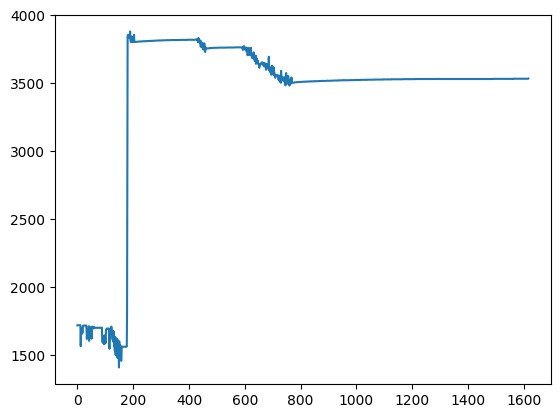

In [26]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [27]:
for i in range(0,values_dates_fs01.shape[0]):
    aux_date=int(values_dates_fs01.iloc[i,2][36:44],16)
    print(i,values_dates_fs01.iloc[i,0],datetime.datetime.fromtimestamp(int(aux_date)))

0 1718 2026-08-14 19:04:42
1 1718 2026-08-14 19:04:42
2 1719 2026-08-14 19:04:42
3 1719 2026-08-14 19:10:02
4 1719 2026-08-14 19:10:02
5 1719 2026-08-14 19:10:02
6 1719 2026-08-14 19:15:22
7 1719 2026-08-14 19:15:22
8 1719 2026-08-14 19:15:22
9 1719 2026-08-14 19:20:42
10 1719 2026-08-14 19:20:42
11 1719 2026-08-14 19:20:42
12 1565 2026-08-14 19:26:43
13 1695 2026-08-14 19:26:43
14 1653 2026-08-14 19:26:43
15 1660 2026-08-14 19:32:03
16 1660 2026-08-14 19:32:03
17 1659 2026-08-14 19:32:03
18 1669 2026-08-14 19:37:23
19 1667 2026-08-14 19:37:23
20 1716 2026-08-14 19:37:23
21 1716 2026-08-14 19:42:43
22 1716 2026-08-14 19:42:43
23 1716 2026-08-14 19:42:43
24 1716 2026-08-14 19:48:03
25 1716 2026-08-14 19:48:03
26 1716 2026-08-14 19:48:03
27 1717 2026-08-14 19:53:23
28 1717 2026-08-14 19:53:23
29 1716 2026-08-14 19:53:23
30 1716 2026-08-14 19:59:53
31 1717 2026-08-14 19:59:53
32 1717 2026-08-14 19:59:53
33 1677 2026-08-14 20:05:13
34 1618 2026-08-14 20:05:13
35 1658 2026-08-14 20:05:13
36

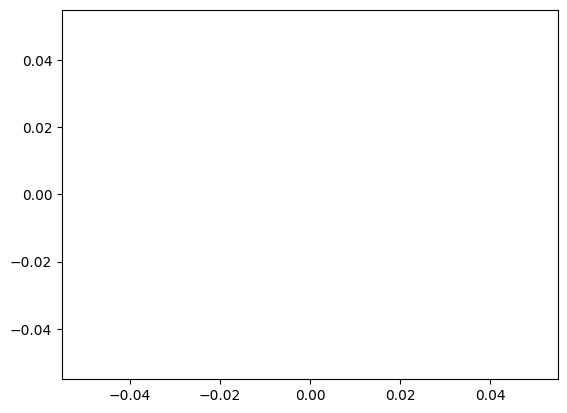

In [28]:
plt.plot(fs02_x_values,fs02_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [29]:
for i in range(0,values_dates_fs02.shape[0]):
    aux_date=int(values_dates_fs02.iloc[i,2][36:44],16)
    print(i,values_dates_fs02.iloc[i,0],datetime.datetime.fromtimestamp(int(aux_date)))